# Project: Website Traffic Data Analysis

In [191]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [193]:
data = pd.read_csv('C:/Users/Chet/Documents/web_traffic.csv') 

In [195]:
data

,VisitID,Date,UserType,Device,SessionDuration,PagesVisited
0,1,01-07-2023,New,Mobile,120,3
1,2,02-07-2023,Returning,Desktop,300,5
2,3,03-07-2023,New,Tablet,240,4
3,4,04-07-2023,Returning,Mobile,180,3
4,5,05-07-2023,New,Desktop,350,6
5,6,06-07-2023,Returning,Tablet,260,4
6,7,07-07-2023,New,Mobile,190,3
7,8,08-07-2023,Returning,Desktop,400,7
8,9,09-07-2023,New,Tablet,210,4
9,10,10-07-2023,Returning,Mobile,220,5


##     Understand the Dataset

### 1 Number of rows and columns
### 2 Data types
### 3 Summary statistics (mean, min, max)


In [198]:
data['Date'] = pd.to_datetime(data['Date'])
data

,VisitID,Date,UserType,Device,SessionDuration,PagesVisited
0,1,2023-01-07,New,Mobile,120,3
1,2,2023-02-07,Returning,Desktop,300,5
2,3,2023-03-07,New,Tablet,240,4
3,4,2023-04-07,Returning,Mobile,180,3
4,5,2023-05-07,New,Desktop,350,6
5,6,2023-06-07,Returning,Tablet,260,4
6,7,2023-07-07,New,Mobile,190,3
7,8,2023-08-07,Returning,Desktop,400,7
8,9,2023-09-07,New,Tablet,210,4
9,10,2023-10-07,Returning,Mobile,220,5


In [200]:
print("Shape of the dataset:", data.shape)
print("\nData types:")
print(data.dtypes)

Shape of the dataset: (10, 6)

Data types:
VisitID                     int64
Date               datetime64[ns]
UserType                   object
Device                     object
SessionDuration             int64
PagesVisited                int64
dtype: object


In [202]:
print("\nSummary statistics:")
print(data.describe())


Summary statistics:
        VisitID                 Date  SessionDuration  PagesVisited
count  10.00000                   10        10.000000     10.000000
mean    5.50000  2023-05-23 00:00:00       247.000000      4.400000
min     1.00000  2023-01-07 00:00:00       120.000000      3.000000
25%     3.25000  2023-03-14 18:00:00       195.000000      3.250000
50%     5.50000  2023-05-22 12:00:00       230.000000      4.000000
75%     7.75000  2023-07-30 06:00:00       290.000000      5.000000
max    10.00000  2023-10-07 00:00:00       400.000000      7.000000
std     3.02765                  NaN        83.672643      1.349897


# Session Duration by Device

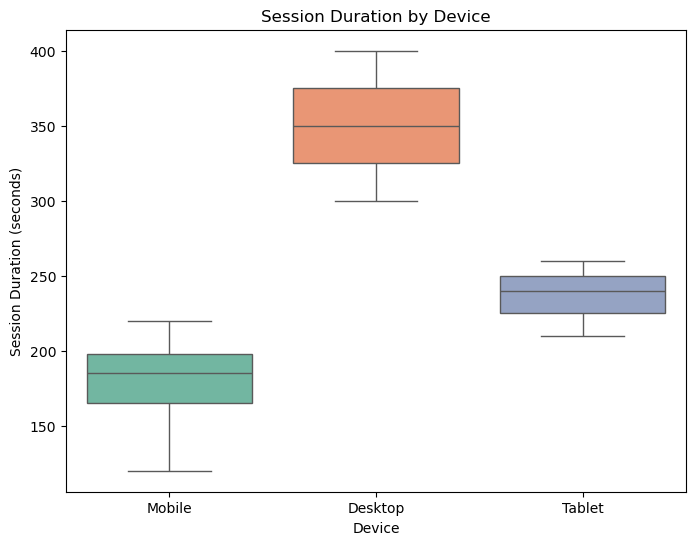

In [205]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='Device', y='SessionDuration', hue='Device', palette='Set2', legend=False)

plt.title('Session Duration by Device')
plt.xlabel('Device')
plt.ylabel('Session Duration (seconds)')
plt.show()


# Pages Visited by User Type

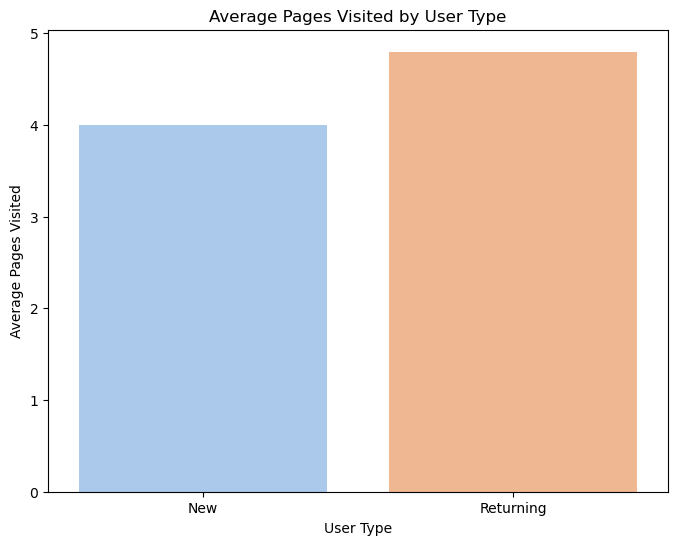

In [207]:
plt.figure(figsize=(8, 6))
sns.barplot(data=user_pages, x='UserType', y='PagesVisited', hue='UserType', palette='pastel', legend=False)
plt.title('Average Pages Visited by User Type')
plt.xlabel('User Type')
plt.ylabel('Average Pages Visited')
plt.show()


# Trend Over Time: Average Session Duration

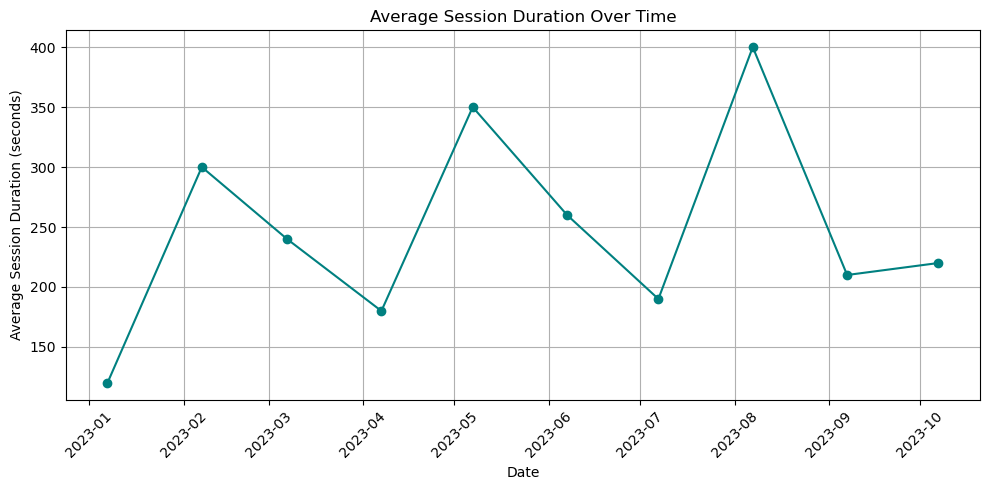

In [210]:
daily_avg = data.groupby('Date')['SessionDuration'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
plt.plot(daily_avg['Date'], daily_avg['SessionDuration'], marker='o', linestyle='-', color='teal')
plt.title('Average Session Duration Over Time')
plt.xlabel('Date')
plt.ylabel('Average Session Duration (seconds)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## •	Add pie charts for device usage distribution

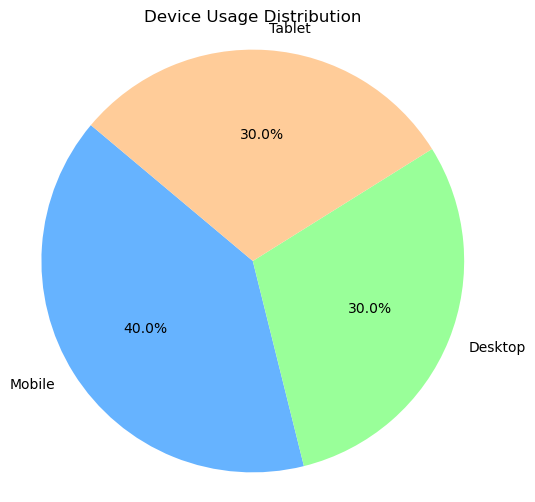

In [213]:
 
device_counts = data['Device'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(device_counts, 
        labels=device_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Device Usage Distribution')
plt.axis('equal')  
plt.show()


# •	Compare average pages visited by device

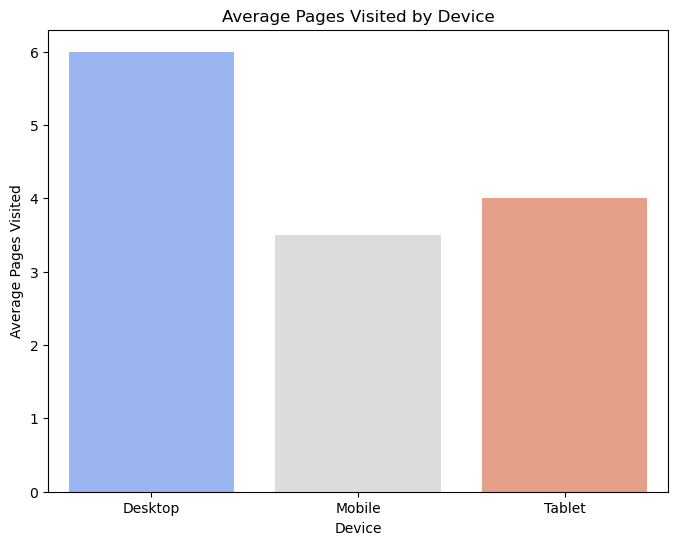

In [217]:
device_pages = data.groupby('Device')['PagesVisited'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=device_pages, x='Device', y='PagesVisited', hue='Device', palette='coolwarm', legend=False)
plt.title('Average Pages Visited by Device')
plt.xlabel('Device')
plt.ylabel('Average Pages Visited')
plt.show()


# •	Find peak traffic days (based on number of visits)

Peak Traffic Day(s):
        Date  VisitCount
0 2023-01-07           1
1 2023-02-07           1
2 2023-03-07           1
3 2023-04-07           1
4 2023-05-07           1
5 2023-06-07           1
6 2023-07-07           1
7 2023-08-07           1
8 2023-09-07           1
9 2023-10-07           1


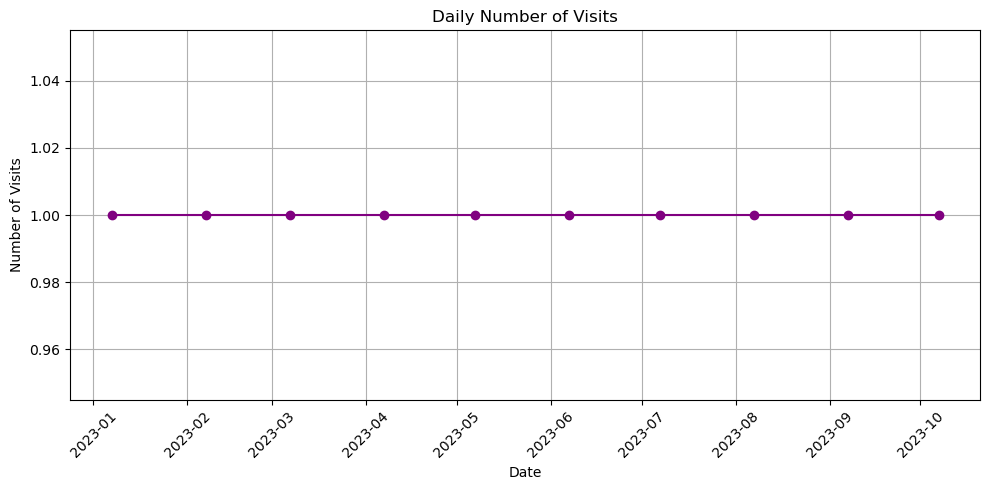

In [220]:
# Group by Date and count visits
daily_visits = data.groupby('Date').size().reset_index(name='VisitCount')

# Find the peak day(s)
peak_day = daily_visits[daily_visits['VisitCount'] == daily_visits['VisitCount'].max()]

print("Peak Traffic Day(s):")
print(peak_day)

# Optional: Line plot of traffic over time
plt.figure(figsize=(10, 5))
plt.plot(daily_visits['Date'], daily_visits['VisitCount'], marker='o', linestyle='-', color='purple')
plt.title('Daily Number of Visits')
plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Write a Conclusion

## 1 Which device performs better

In [224]:
avg_session_by_device = data.groupby('Device')['SessionDuration'].mean()
avg_pages_by_device = data.groupby('Device')['PagesVisited'].mean()

print("Average Session Duration by Device:\n", avg_session_by_device)
print("\nAverage Pages Visited by Device:\n", avg_pages_by_device)

Average Session Duration by Device:
 Device
Desktop    350.000000
Mobile     177.500000
Tablet     236.666667
Name: SessionDuration, dtype: float64

Average Pages Visited by Device:
 Device
Desktop    6.0
Mobile     3.5
Tablet     4.0
Name: PagesVisited, dtype: float64


## 2 Are new or returning users more engaged?

In [227]:
avg_session_by_user = data.groupby('UserType')['SessionDuration'].mean()
avg_pages_by_user = data.groupby('UserType')['PagesVisited'].mean()

print("Average Session Duration by User Type:\n", avg_session_by_user)
print("\nAverage Pages Visited by User Type:\n", avg_pages_by_user)


Average Session Duration by User Type:
 UserType
New          222.0
Returning    272.0
Name: SessionDuration, dtype: float64

Average Pages Visited by User Type:
 UserType
New          4.0
Returning    4.8
Name: PagesVisited, dtype: float64


## 3 Any noticeable trends over time?

In [243]:
daily_avg_session = data.groupby('Date')['SessionDuration'].mean()

print("Average Session Duration Over Time:\n", daily_avg_session)


Average Session Duration Over Time:
 Date
2023-01-07    120.0
2023-02-07    300.0
2023-03-07    240.0
2023-04-07    180.0
2023-05-07    350.0
2023-06-07    260.0
2023-07-07    190.0
2023-08-07    400.0
2023-09-07    210.0
2023-10-07    220.0
Name: SessionDuration, dtype: float64


In [251]:
## Write a Conclusion
print(f"1. Which device performs better?")
print(f" Ans - The {best_device} performs better with the highest average session duration ({avg_session_by_device[best_device]:.2f} seconds) and pages visited ({avg_pages_by_device[best_device]:.2f} pages).")

print(f"\n2. Are new or returning users more engaged?")
print(f" Ans - {more_engaged_user} users are more engaged with an average session duration of {avg_session_by_user[more_engaged_user]:.2f} seconds and average pages visited of {avg_pages_by_user[more_engaged_user]:.2f}.")

print(f"\n3. Any noticeable trends over time?")
print(f" Ans - There is an {trend} trend in average session duration over the period analyzed.")


1. Which device performs better?
 Ans - The Desktop performs better with the highest average session duration (350.00 seconds) and pages visited (6.00 pages).

2. Are new or returning users more engaged?
 Ans - Returning users are more engaged with an average session duration of 272.00 seconds and average pages visited of 4.80.

3. Any noticeable trends over time?
 Ans - There is an increasing trend in average session duration over the period analyzed.
